In [1]:
from lzn.data_processing.extract_energies import *
from lzn.data_processing.rmsd_min import find_rmsd_min
from lzn.universal import *
from lzn.atoms_construction.construct_catads_v1 import read_mspa_frame
from lzn.data_processing.find_symmetry_equivalent_sites import symmetry_equiv_sites, symm_fxn_i

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from ase.io import read

In [2]:
atoms_symmtry_ref = read(
    to_path("~/TiO2_organized/05_mspa_clusters/tio12CDa_opt-pbe0_def2tzvpS_hsM.xyz"),
    index=1
)
dict_equiv = symmetry_equiv_sites(
    atoms_symmtry_ref,
    symm_fxn_i,
)

exchange_list = dict_equiv["Ti"] + dict_equiv["O"]
print(exchange_list)

[(1, 33), (2, 27), (6, 34), (9, 21), (13, 18), (16, 24), (0, 30), (3, 32), (4, 31), (5, 26), (7, 29), (8, 35), (10, 19), (11, 20), (12, 28), (14, 25), (15, 22), (17, 23)]


In [3]:
# Read Vsmax
atoms_omol, rankings_omol = read_mspa_frame("~/TiO2_organized/05_mspa_clusters/tio12CDa_opt-omol25_lowS_hsM.xyz", "Vsmax")
atoms_svp ,rankings_svp = read_mspa_frame("~/TiO2_organized/05_mspa_clusters/tio12CDa_opt-pbe0_def2svpS_hsM.xyz", "Vsmax")

name_list_dft = [f"co_site{rankings_svp[2*i][0]},{rankings_svp[2*i+1][0]}" for i in range(len(rankings_svp)//2)]
potential_list_svp_h = [rankings_svp[2*i][2] for i in range(len(rankings_svp)//2)]
potential_list_svp_l = [rankings_svp[2*i+1][2] for i in range(len(rankings_svp)//2)]
potential_list_av_dft = [np.average([potential_list_svp_h[i], potential_list_svp_l[i]]) for i in range(len(name_list_dft))]

name_list_mlip = [f"co_site{rankings_omol[i][0]}" for i in range(len(rankings_svp))]
potential_list_omol = [rankings_omol[i][2] for i in range(len(rankings_omol))]

df_potentials_dft = pd.DataFrame(list(zip(name_list_dft, potential_list_av_dft)), columns=["PBE0 opt", "Vsmax av"])
df_potentials_mlip = pd.DataFrame(list(zip(name_list_mlip, potential_list_omol)), columns=["MLIP opt", "Vsmax"])
df_potentials_dft

,PBE0 opt,Vsmax av
0,"co_site36,37",124.490
1,"co_site38,39",105.965
2,"co_site40,41",61.490
3,"co_site42,43",59.370
4,"co_site44,45",49.940
5,"co_site46,47",41.505
6,"co_site48,49",39.925
7,"co_site50,51",35.410
8,"co_site52,53",26.735
9,"co_site54,55",22.585


In [4]:
df_potentials_mlip

,MLIP opt,Vsmax
0,co_site36,124.64
1,co_site37,124.60
2,co_site38,109.17
3,co_site39,109.15
4,co_site40,60.61
5,co_site41,60.42
6,co_site42,58.75
7,co_site43,58.42
8,co_site44,51.22
9,co_site45,51.16


In [5]:
# Functions that read energies
def traj_to_energies_df(data_dir, matching, col_name, name_start = 1, name_end = 3) -> pd.DataFrame:
    data_dir = to_path(data_dir)

    extract_name = lambda s, *args: '_'.join(s.stem.split("_")[name_start: name_end])

    e_list = batch_do(
        extract_ase_energy,
        data_dir,
        matching,
    )

    name_list = batch_do(
        extract_name,
        data_dir,
        matching,
    )

    df_inherent_mlip = pd.DataFrame(list(zip(name_list, e_list)), columns=["Structures", col_name])

    return df_inherent_mlip


def glog_to_energies_df(data_dir, matching, col_name, name_start = 1, name_end = 3) -> pd.DataFrame:
    data_dir = to_path(data_dir)

    extract_name = lambda s, *args: '_'.join(s.stem.split("_")[name_start: name_end])

    e_list = batch_do(
        extract_g16_energy,
        data_dir,
        matching,
    )

    name_list = batch_do(
        extract_name,
        data_dir,
        matching,
    )

    df_inherent_g16 = pd.DataFrame(list(zip(name_list, e_list)), columns=["Structures", col_name])

    return df_inherent_g16



### Table set 1: Vsmax vs Eint

###### MLIP

In [6]:
# MLIP Reactants energies
energy_inherent_mlip_ads = extract_ase_energy("~/TiO2_organized/04_adsorbates_mlip_opt/co_opt-omol25_low_s.traj")
energy_inherent_mlip_cat = extract_ase_energy("~/TiO2_organized/02_cluster_mlip_opt/tio12CDa_opt-omol25_low_s.traj")
energy_inherent_mlip_sum = energy_inherent_mlip_ads + energy_inherent_mlip_cat
print(energy_inherent_mlip_sum)

# MLIP Products energies
df_inherent_mlip_catads = traj_to_energies_df("~/TiO2_organized/07_catads_mlip_opt_from_tzvp", "tio12CDa_co_site*_opt-omol25_low.traj", "omol25 inh au")
df_inherent_mlip_catads.loc[:,"omol25 inh dE kJ/mol"] = (df_inherent_mlip_catads.loc[:,"omol25 inh au"] - energy_inherent_mlip_sum) * hartree_to_kJdmol
df_inherent_mlip_tot = pd.concat([df_potentials_mlip, df_inherent_mlip_catads.loc[:,"omol25 inh dE kJ/mol"]], axis = 1)

df_inherent_mlip_tot

-7.873585899068517
22 matching files
22 matching files


,MLIP opt,Vsmax,omol25 inh dE kJ/mol
0,co_site36,124.64,-40.340542
1,co_site37,124.60,-40.343486
2,co_site38,109.17,-38.104195
3,co_site39,109.15,-38.102723
4,co_site40,60.61,-22.265741
5,co_site41,60.42,-22.299603
6,co_site42,58.75,-18.751483
7,co_site43,58.42,-18.722038
8,co_site44,51.22,-13.286495
9,co_site45,51.16,-13.282078


###### DFT

In [7]:
# svp Reactants energies
energy_inherent_svp_cat = extract_g16_energy(
    "~/TiO2_organized/02_cluster_g16_opt/tio12CDa_opt-pbe0_def2svp_cm-Ci.log")
energy_inherent_svp_ads = extract_g16_energy("~/TiO2_organized/04_adsorbates_g16_opt/co_opt-pbe0_def2svp.log")
energy_inherent_svp_sum = energy_inherent_svp_ads + energy_inherent_svp_cat
print(energy_inherent_svp_sum)

# svp Products energies
df_inherent_dft_catads = glog_to_energies_df("~/TiO2_organized/07_catads_g16_opt", "tio12CDa_co_site*_opt-pbe0_def2svp.log", "svp inh au")
df_inherent_dft_catads.loc[:,"pbe0svp inh dE kJ/mol"] = (df_inherent_dft_catads.loc[:,"svp inh au"] - energy_inherent_svp_sum) * hartree_to_kJdmol
df_inherent_dft_tot = pd.concat([df_potentials_dft, df_inherent_dft_catads.loc[:,"pbe0svp inh dE kJ/mol"]], axis = 1)


df_inherent_dft_tot

-12107.84457068623
11 matching files
11 matching files


,PBE0 opt,Vsmax av,pbe0svp inh dE kJ/mol
0,"co_site36,37",124.490,-66.650234
1,"co_site38,39",105.965,-62.219179
2,"co_site40,41",61.490,-41.001209
3,"co_site42,43",59.370,-45.912730
4,"co_site44,45",49.940,-32.228105
5,"co_site46,47",41.505,-29.999319
6,"co_site48,49",39.925,-31.817477
7,"co_site50,51",35.410,-39.841264
8,"co_site52,53",26.735,-20.985718
9,"co_site54,55",22.585,-24.837325


### Table 2: Check structures

In [8]:
# List copy from the output of check_opt_consistency_dft_mlip.py
# which ran omol25 opt for svp opted structure
# to check whether omol25 and svp got the same local minimum.
equivalent_sites = [('tio12CDa_co_site36_opt-omol25_low.xyz', np.float64(0.021975639841387295)), ('tio12CDa_co_site39_opt-omol25_low.xyz', np.float64(0.018126892879271748)), ('tio12CDa_co_site41_opt-omol25_low.xyz', np.float64(0.08266056998938724)), ('tio12CDa_co_site42_opt-omol25_low.xyz', np.float64(0.02030011412058259)), ('tio12CDa_co_site45_opt-omol25_low.xyz', np.float64(0.04932897056648406)), ('tio12CDa_co_site47_opt-omol25_low.xyz', np.float64(0.021510191689815678)), ('tio12CDa_co_site49_opt-omol25_low.xyz', np.float64(0.021813845887866275)), ('tio12CDa_co_site50_opt-omol25_low.xyz', np.float64(0.010154195896400932)), ('tio12CDa_co_site53_opt-omol25_low.xyz', np.float64(0.12443309873259278)), ('tio12CDa_co_site54_opt-omol25_low.xyz', np.float64(0.010546902691399766)), ('tio12CDa_co_site56_opt-omol25_low.xyz', np.float64(0.014494305465105004))]

# col[-1]: RMSD
rmsd_list = [i[1] for i in equivalent_sites]
df_rmsd = pd.DataFrame(rmsd_list, columns=["rmsd"])

# col[-3]: MLIP optimized (DFT optimized structure) structure
df_E_pbe0_then_omol_catads = traj_to_energies_df("~/TiO2_organized/09_catads_check_consistency", "tio12CDa_co_site*_opt-pbe0_def2svp.traj", "pbe0+omol au")
df_E_pbe0_then_omol_catads.loc[:,"pbe0+omol dE kJ/mol"] = (df_E_pbe0_then_omol_catads.loc[:,"pbe0+omol au"] - energy_inherent_mlip_sum) * hartree_to_kJdmol

# col[-2]: MLIP optimized structure that corresponding to DFT opt
equivalent_sites_traj_list = [i[0][:-4] + ".traj" for i in equivalent_sites]
df_E_omol_equivalent_catads = traj_to_energies_df("~/TiO2_organized/07_catads_mlip_opt_from_tzvp", equivalent_sites_traj_list, "omol eq au")
df_E_omol_equivalent_catads.loc[:,"omol eq dE kJ/mol"] = (df_E_omol_equivalent_catads.loc[:,"omol eq au"] - energy_inherent_mlip_sum) * hartree_to_kJdmol

df_E_pbe0_then_omol_catads["pbe0+omol dE kJ/mol"]



11 matching files
11 matching files
11 matching files
11 matching files


0    -3.178642e+07
1    -3.178642e+07
2    -3.178640e+07
3    -3.178640e+07
4    -3.178639e+07
5    -3.178639e+07
6    -3.178639e+07
7    -3.178640e+07
8    -3.178639e+07
9    -3.178639e+07
10   -3.178639e+07
Name: pbe0+omol dE kJ/mol, dtype: float64

In [9]:
df_check = pd.concat([df_inherent_dft_tot, df_E_pbe0_then_omol_catads.iloc[:,-1],df_E_omol_equivalent_catads.iloc[:,-1], df_rmsd,], axis=1)
df_check.loc[:,"ddE kJ/mol"] = df_check.loc[:,"pbe0+omol dE kJ/mol"] - df_check.loc[:,"omol eq dE kJ/mol"]
df_check

,PBE0 opt,Vsmax av,pbe0svp inh dE kJ/mol,pbe0+omol dE kJ/mol,omol eq dE kJ/mol,rmsd,ddE kJ/mol
0,"co_site36,37",124.490,-66.650234,-3.178642e+07,-40.340542,0.021976,-3.178638e+07
1,"co_site38,39",105.965,-62.219179,-3.178642e+07,-38.102723,0.018127,-3.178638e+07
2,"co_site40,41",61.490,-41.001209,-3.178640e+07,-22.299603,0.082661,-3.178637e+07
3,"co_site42,43",59.370,-45.912730,-3.178640e+07,-18.751483,0.020300,-3.178638e+07
4,"co_site44,45",49.940,-32.228105,-3.178639e+07,-13.282078,0.049329,-3.178638e+07
5,"co_site46,47",41.505,-29.999319,-3.178639e+07,-10.932369,0.021510,-3.178638e+07
6,"co_site48,49",39.925,-31.817477,-3.178639e+07,-13.488193,0.021814,-3.178638e+07
7,"co_site50,51",35.410,-39.841264,-3.178640e+07,-21.715120,0.010154,-3.178638e+07
8,"co_site52,53",26.735,-20.985718,-3.178639e+07,-9.211310,0.124433,-3.178638e+07
9,"co_site54,55",22.585,-24.837325,-3.178639e+07,-11.811301,0.010547,-3.178638e+07


### TZVP sp of MLIP opt structures

In [10]:
# MLIP Reactants tzvp energies
energy_tzvp_mlip_ads = extract_g16_energy("~/TiO2_organized/04_adsorbates_g16_opt/co_opt-pbe0_def2tzvp.log")
energy_tzvp_mlip_cat = extract_g16_energy("~/TiO2_organized/04_cluster_g16_sp/tio12CDa_sp-pbe0_def2tzvp_opt-omol25_low.log")
energy_tzvp_mlip_sum = energy_tzvp_mlip_ads + energy_tzvp_mlip_cat
print(energy_tzvp_mlip_sum)

# MLIP Products tzvp energies
df_tzvp_mlip_catads = glog_to_energies_df("~/TiO2_organized/09_catads_g16_sp", "tio12CDa_co_site*_opt-omol25_low_sp-pbe0_def2tzvp.log", "omol tzvp au")
df_tzvp_mlip_catads.loc[:,"omol tzvp dE kJ/mol"] = (df_tzvp_mlip_catads.loc[:,"omol tzvp au"] - energy_tzvp_mlip_sum) * hartree_to_kJdmol
df_mlip_tot = pd.concat([df_inherent_mlip_tot, df_tzvp_mlip_catads.loc[:,"omol tzvp dE kJ/mol"]], axis = 1)

df_mlip_tot

-12111.413672386321
22 matching files
22 matching files


,MLIP opt,Vsmax,omol25 inh dE kJ/mol,omol tzvp dE kJ/mol
0,co_site36,124.64,-40.340542,-59.174120
1,co_site37,124.60,-40.343486,-59.132637
2,co_site38,109.17,-38.104195,-54.465025
3,co_site39,109.15,-38.102723,-54.482879
4,co_site40,60.61,-22.265741,-29.574770
5,co_site41,60.42,-22.299603,-29.537488
6,co_site42,58.75,-18.751483,-37.256192
7,co_site43,58.42,-18.722038,-37.162462
8,co_site44,51.22,-13.286495,-21.573300
9,co_site45,51.16,-13.282078,-21.164509


In [11]:
# svp Reactants tzvp energies
energy_tzvp_svp_ads = extract_g16_energy("~/TiO2_organized/04_adsorbates_g16_opt/co_opt-pbe0_def2tzvp.log")
energy_tzvp_svp_cat = extract_g16_energy("~/TiO2_organized/04_cluster_g16_sp/tio12CDa_sp-pbe0_def2tzvp_opt-pbe0_def2svp.log")
energy_tzvp_svp_sum = energy_tzvp_svp_ads + energy_tzvp_svp_cat
print(energy_tzvp_svp_sum)

# svp Products tzvp energies
df_tzvp_svp_catads = glog_to_energies_df("~/TiO2_organized/09_catads_g16_sp", "tio12CDa_co_site*_opt-pbe0_def2svp_sp-pbe0_def2tzvp.log", "svp tzvp au")
df_tzvp_svp_catads.loc[:,"svp tzvp dE kJ/mol"] = (df_tzvp_svp_catads.loc[:,"svp tzvp au"] - energy_tzvp_svp_sum) * hartree_to_kJdmol
df_dft_tot = pd.concat([df_inherent_dft_tot, df_tzvp_svp_catads.loc[:,"svp tzvp dE kJ/mol"]], axis = 1)

df_dft_tot

-12111.412965186657
11 matching files
11 matching files


,PBE0 opt,Vsmax av,pbe0svp inh dE kJ/mol,svp tzvp dE kJ/mol
0,"co_site36,37",124.490,-66.650234,-60.407054
1,"co_site38,39",105.965,-62.219179,-55.740755
2,"co_site40,41",61.490,-41.001209,-30.005089
3,"co_site42,43",59.370,-45.912730,-38.106854
4,"co_site44,45",49.940,-32.228105,-23.703892
5,"co_site46,47",41.505,-29.999319,-19.933675
6,"co_site48,49",39.925,-31.817477,-23.838317
7,"co_site50,51",35.410,-39.841264,-27.939347
8,"co_site52,53",26.735,-20.985718,-14.810277
9,"co_site54,55",22.585,-24.837325,-15.651224


### RMSD between omol25 and its inversion

In [12]:
def center_inversion_read(atoms_path):
    atoms = read(atoms_path)
    energy = atoms.get_potential_energy()

    #  Step 1: center inversion
    atoms_inv_pos = atoms.positions * -1.
    atoms.positions[:] = atoms_inv_pos

    # Step 2: swap indices
    order = [None] * 36 + [36, 37] # generate an index list. Empty in (TiO2)12, plus a CO
    for (i, j) in exchange_list:
        order[i], order[j] = j, i

    atoms = atoms[order]
    return atoms, energy

def compare_even_and_inv_odd(even_path, odd_path):
    print(f"{even_path.name}, {odd_path.name}")
    atoms_even = read(even_path)
    energy_even = atoms_even.get_potential_energy()
    atoms_odd, energy_odd = center_inversion_read(odd_path)
    rot, b, rmsd_min = find_rmsd_min(atoms_even, atoms_odd)
    ddE = energy_odd - energy_even
    return rmsd_min, ddE

file_dir = to_path("~/TiO2_organized/07_catads_mlip_opt_from_tzvp")
even_file_list = [f"tio12CDa_co_site{i}_opt-omol25_low.traj" for i in range(36,58,2)]
odd_file_list = [f"tio12CDa_co_site{i}_opt-omol25_low.traj" for i in range(37,58,2)]

rmsd_even_odd = []
ddE_list = []

for i in range(len(even_file_list)):
    even_path = file_dir / even_file_list[i]
    odd_path = file_dir / odd_file_list[i]

    rmsd_min, ddE = compare_even_and_inv_odd(even_path, odd_path)
    rmsd_even_odd.append(rmsd_min)
    ddE_list.append(ddE * eV_to_kJdmol)

# Write df_omol_even_odd dataframe
df_omol_even_odd = pd.DataFrame(zip(df_check["PBE0 opt"].to_list(), ddE_list, rmsd_even_odd), columns=["site #","ddE kJ/mol","rmsd min"])
df_omol_even_odd.loc[:,"abs ddE"] = abs(df_omol_even_odd.loc[:,"ddE kJ/mol"])
df_omol_even_odd

tio12CDa_co_site36_opt-omol25_low.traj, tio12CDa_co_site37_opt-omol25_low.traj


RMSD (Å): 0.01120826835147033
tio12CDa_co_site38_opt-omol25_low.traj, tio12CDa_co_site39_opt-omol25_low.traj
RMSD (Å): 0.0006179808636576324
tio12CDa_co_site40_opt-omol25_low.traj, tio12CDa_co_site41_opt-omol25_low.traj
RMSD (Å): 0.017850452566156548
tio12CDa_co_site42_opt-omol25_low.traj, tio12CDa_co_site43_opt-omol25_low.traj
RMSD (Å): 0.013462668854026675
tio12CDa_co_site44_opt-omol25_low.traj, tio12CDa_co_site45_opt-omol25_low.traj
RMSD (Å): 0.005975712378634635
tio12CDa_co_site46_opt-omol25_low.traj, tio12CDa_co_site47_opt-omol25_low.traj
RMSD (Å): 0.004146788597288424
tio12CDa_co_site48_opt-omol25_low.traj, tio12CDa_co_site49_opt-omol25_low.traj
RMSD (Å): 0.0014127508560876439
tio12CDa_co_site50_opt-omol25_low.traj, tio12CDa_co_site51_opt-omol25_low.traj
RMSD (Å): 0.003956857732305057
tio12CDa_co_site52_opt-omol25_low.traj, tio12CDa_co_site53_opt-omol25_low.traj
RMSD (Å): 0.007630173474488589
tio12CDa_co_site54_opt-omol25_low.traj, tio12CDa_co_site55_opt-omol25_low.traj
RMSD (Å):

,site #,ddE kJ/mol,rmsd min,abs ddE
0,"co_site36,37",-0.002944,0.011208,0.002944
1,"co_site38,39",0.001472,0.000618,0.001472
2,"co_site40,41",-0.033862,0.017850,0.033862
3,"co_site42,43",0.029445,0.013463,0.029445
4,"co_site44,45",0.004417,0.005976,0.004417
5,"co_site46,47",-0.001472,0.004147,0.001472
6,"co_site48,49",0.004417,0.001413,0.004417
7,"co_site50,51",-0.011778,0.003957,0.011778
8,"co_site52,53",0.030917,0.007630,0.030917
9,"co_site54,55",0.000000,0.002787,0.000000


### Summary

In [15]:
df_check

,PBE0 opt,Vsmax av,pbe0svp inh dE kJ/mol,pbe0+omol dE kJ/mol,omol eq dE kJ/mol,rmsd,ddE kJ/mol
0,"co_site36,37",124.490,-66.650234,-3.178642e+07,-40.340542,0.021976,-3.178638e+07
1,"co_site38,39",105.965,-62.219179,-3.178642e+07,-38.102723,0.018127,-3.178638e+07
2,"co_site40,41",61.490,-41.001209,-3.178640e+07,-22.299603,0.082661,-3.178637e+07
3,"co_site42,43",59.370,-45.912730,-3.178640e+07,-18.751483,0.020300,-3.178638e+07
4,"co_site44,45",49.940,-32.228105,-3.178639e+07,-13.282078,0.049329,-3.178638e+07
5,"co_site46,47",41.505,-29.999319,-3.178639e+07,-10.932369,0.021510,-3.178638e+07
6,"co_site48,49",39.925,-31.817477,-3.178639e+07,-13.488193,0.021814,-3.178638e+07
7,"co_site50,51",35.410,-39.841264,-3.178640e+07,-21.715120,0.010154,-3.178638e+07
8,"co_site52,53",26.735,-20.985718,-3.178639e+07,-9.211310,0.124433,-3.178638e+07
9,"co_site54,55",22.585,-24.837325,-3.178639e+07,-11.811301,0.010547,-3.178638e+07


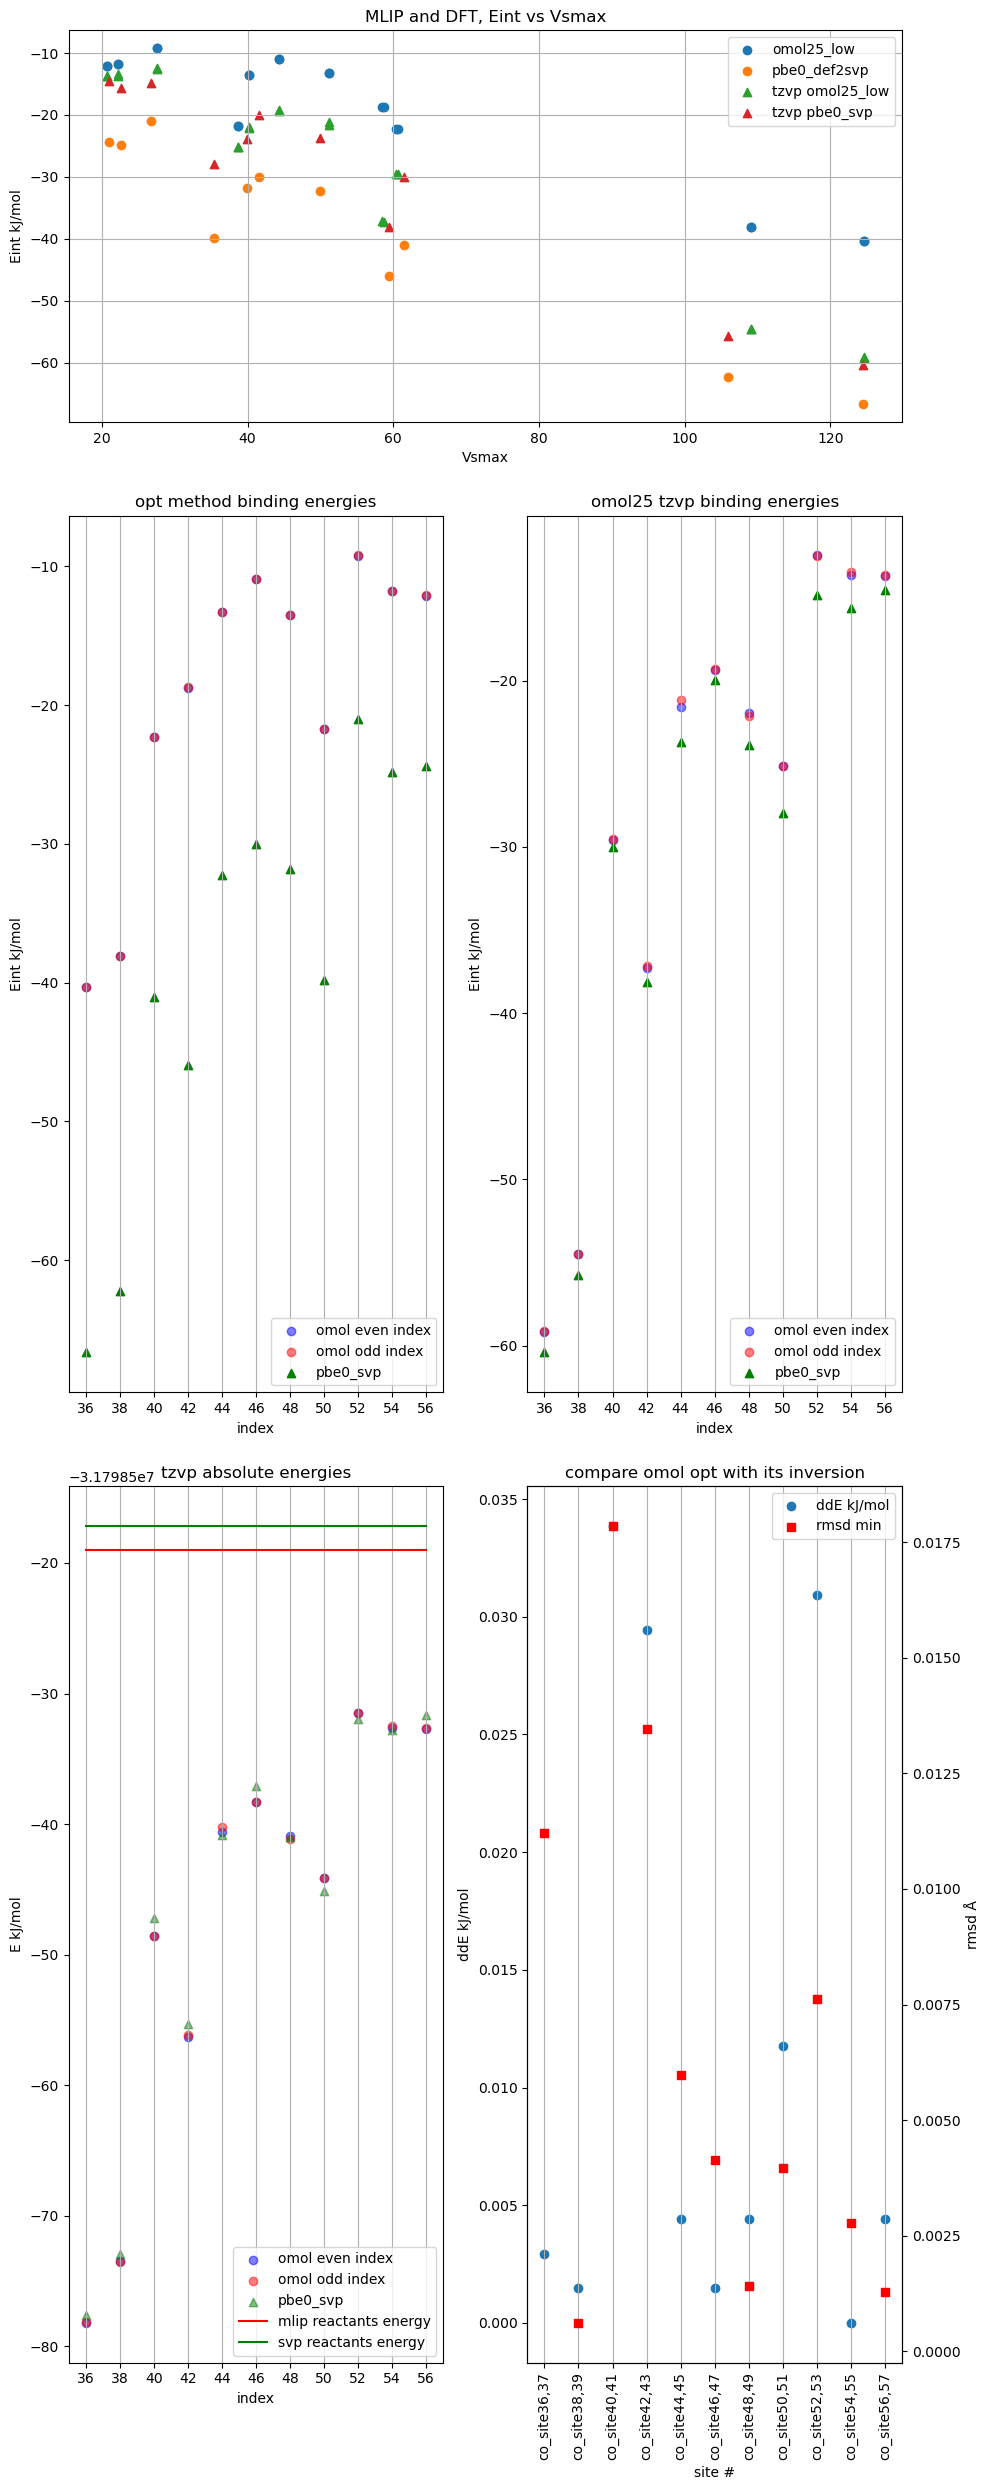

In [14]:
fig1 = plt.figure(1, figsize = (10,25))
gs = fig1.add_gridspec(5,2)

ax_top = fig1.add_subplot(gs[0,:])
ax_left = fig1.add_subplot(gs[1:3,0])
ax_right = fig1.add_subplot(gs[1:3,1])
ax_bottom = fig1.add_subplot(gs[3:,0])
ax_last = fig1.add_subplot(gs[3:,1])

# ax_top omol25 and svp, inherent and tzvp energies vs Vsmax
ax_top.set_title('MLIP and DFT, Eint vs Vsmax')

ax_top.scatter(
    df_inherent_mlip_tot["Vsmax"],
    df_inherent_mlip_tot["omol25 inh dE kJ/mol"],
    label="omol25_low",
)
ax_top.scatter(
    df_inherent_dft_tot["Vsmax av"],
    df_inherent_dft_tot["pbe0svp inh dE kJ/mol"],
    label="pbe0_def2svp",
)
ax_top.scatter(
    df_inherent_mlip_tot["Vsmax"],
    df_mlip_tot.iloc[:,-1],
    label="tzvp omol25_low",
    marker="^",
)
ax_top.scatter(
    df_inherent_dft_tot["Vsmax av"],
    df_dft_tot.iloc[:,-1],
    label="tzvp pbe0_svp",
    marker="^",
)

ax_top.legend()
ax_top.set_xlabel("Vsmax")
ax_top.set_ylabel("Eint kJ/mol")
ax_top.grid(True)

# ax_left omol25 and svp inherent energies vs index
ax_left.set_title("opt method binding energies")

omol_energies_list = df_inherent_mlip_tot.iloc[:,-1].to_list()
len_this_list = len(omol_energies_list)
index_even = [i*2 for i in range(len_this_list//2)]
index_odd = [i*2+1 for i in range(len_this_list//2)]
index_even_x = [i*2+36 for i in range(len_this_list//2)]

svp_energies_list = df_inherent_dft_tot.iloc[:,-1].to_list()
svp_then_omol_list = df_check.loc[:,"pbe0+omol dE kJ/mol"].to_list()

ax_left.scatter(
    index_even_x,
    [omol_energies_list[i] for i in index_even],
    label="omol even index",
    color="blue",
    alpha=0.5
)
ax_left.scatter(
    index_even_x,
    [omol_energies_list[i] for i in index_odd],
    label="omol odd index",
    color="red",
    alpha=0.5
)
ax_left.scatter(
    index_even_x,
    svp_energies_list,
    label="pbe0_svp",
    color="g",
    marker="^",
    alpha=.99
)
# ax_left.scatter(
#     index_even_x,
#     svp_then_omol_list,
#     label="pbe0 then omol",
#     color="green",
#     marker="x",
#     alpha=0.5
# )

ax_left.legend(loc="lower right")
ax_left.set_xticks(index_even_x)
ax_left.grid(axis='x')
ax_left.set_xlabel("index")
ax_left.set_ylabel("Eint kJ/mol")

# ax_right omol25 tzvp energies vs index
ax_right.set_title("omol25 tzvp binding energies")

omol_tzvp_list = df_mlip_tot.iloc[:,-1].to_list()
len_this_list = len(omol_energies_list)
index_even = [i*2 for i in range(len_this_list//2)]
index_odd = [i*2+1 for i in range(len_this_list//2)]
index_even_x = [i*2+36 for i in range(len_this_list//2)]

ax_right.scatter(
    index_even_x,
    [omol_tzvp_list[i] for i in index_even],
    label="omol even index",
    color="blue",
    alpha=0.5
)
ax_right.scatter(
    index_even_x,
    [omol_tzvp_list[i] for i in index_odd],
    label="omol odd index",
    color="red",
    alpha=0.5
)
ax_right.scatter(
    index_even_x,
    df_dft_tot.iloc[:,-1],
    label="pbe0_svp",
    marker="^",
    color="g",
)

ax_right.legend(loc="lower right")
ax_right.set_xticks(index_even_x)
ax_right.grid(axis='x')
ax_right.set_xlabel("index")
ax_right.set_ylabel("Eint kJ/mol")

# ax_bottom absolute tzvp energies vs indices
ax_bottom.set_title("tzvp absolute energies")

mlip_tzvp_abs_list = df_tzvp_mlip_catads.loc[:,"omol tzvp au"].to_list()
mlip_tzvp_abs_list = [i * hartree_to_kJdmol for i in mlip_tzvp_abs_list]

ax_bottom.scatter(
    index_even_x,
    [mlip_tzvp_abs_list[i] for i in index_even],
    label="omol even index",
    color="blue",
    alpha=0.5
)
ax_bottom.scatter(
    index_even_x,
    [mlip_tzvp_abs_list[i] for i in index_odd],
    label="omol odd index",
    color="red",
    alpha=0.5
)
ax_bottom.scatter(
    index_even_x,
    df_tzvp_svp_catads.loc[:,"svp tzvp au"] * hartree_to_kJdmol,
    label="pbe0_svp",
    color="green",
    marker="^",
    alpha=0.5,
)
ax_bottom.plot(
    index_even_x,
    [(energy_tzvp_mlip_sum * hartree_to_kJdmol)]*(len_this_list//2),
    label="mlip reactants energy",
    color="red",
)
ax_bottom.plot(
    index_even_x,
    [(energy_tzvp_svp_sum * hartree_to_kJdmol)]*(len_this_list//2),
    label="svp reactants energy",
    color="green",
)

ax_bottom.legend(loc="lower right")
ax_bottom.set_xticks(index_even_x)
ax_bottom.grid(axis='x')
ax_bottom.set_xlabel("index")
ax_bottom.set_ylabel("E kJ/mol")


# axis last
ax_last.set_title("compare omol opt with its inversion")
ax_last2 = ax_last.twinx()

ax_last.scatter(
    df_omol_even_odd["site #"],
    df_omol_even_odd["abs ddE"],
    label="ddE kJ/mol",
)

ax_last2.scatter(
    df_omol_even_odd["site #"],
    df_omol_even_odd["rmsd min"],
    label="rmsd min",
    color="red",
    marker="s"
)

ax_last.set_xlabel("site #")
ax_last.set_ylabel("ddE kJ/mol"),
ax_last2.set_ylabel("rmsd Å")
ax_last.tick_params(axis="x", rotation=90)
ax_last.grid(axis="x")

lines1, labels1 = ax_last.get_legend_handles_labels()
lines2, labels2 = ax_last2.get_legend_handles_labels()

ax_last.legend(lines1 + lines2, labels1 + labels2, loc="best")

fig1.tight_layout()
plt.show()